# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.47) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.40)), and
derive its variance (Eq. (2.42)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.43)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.44)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.47),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

### Ex.2b)

The expectation firstly predicts all values $y_i$ of y. Then the mean bias, mean variance and mean noise is calculated from this single prediction. As we resample the data, with new random noise, we get a new prediction of all $y_i$ and therefore new values of mean bias, -variance and -noise. In the end, we have collected a series of mean values for each parameter (bias, variance, noise). Finally, we take the average of all of the mean values of bias, variance and noise, and the sum of these turns out to be the estimated error. 

The bias term measures how far the average polynomial, fitted for many datasets, is from the true underlying function $f(x)$. A polynomial with few degrees might be too simple and therefore systematically miss the true curve, giving high bias. The bias decreases with model complexity. 

The variance term measures how much the prediction moves when the training set is redrawn with new random errors. A very flexible polynomial degree migh wiggle a lot, depending on the particular data, giving high variance. The variance increases with model complexity.

The noise term measures the randomness that is intrinsic to the observations and cannot be eliminated just by choosing a better polynomial. 

The test error is the sum of these. It falls when the bias falls and rises when the variance takes over. 

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [520]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.47): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

C:\Users\noral\AppData\Local\Temp\ipykernel_25120\1103959489.py:26: RuntimeWarning: overflow encountered in square
  error[d] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
C:\Users\noral\AppData\Local\Temp\ipykernel_25120\1103959489.py:27: RuntimeWarning: overflow encountered in square
  bias[d] = np.mean((y_test - np.mean(y_pred, axis = 1, keepdims=True))**2)
C:\Users\noral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\noral\AppData\Local\Temp\ipykernel_25120\1103959489.py:26: RuntimeWarning: overflow encountered in square
  error[d] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
C:\Users\noral\AppData\Local\Temp\ipykernel_25120\1103959489.py:27: RuntimeWarning: overflow encountered in square
  bias[d] = np.mean((y_test - np.mean(y_pred, axis = 1, keepdims=T

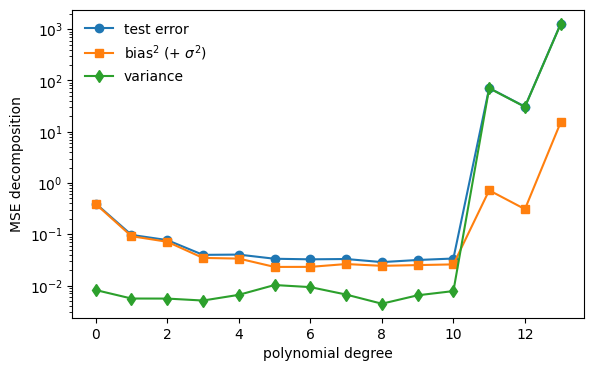

degree  0: error 0.3980 bias^2 0.3898var 0.0082 sum 0.3980
degree  1: error 0.0972 bias^2 0.0917var 0.0056 sum 0.0972
degree  2: error 0.0770 bias^2 0.0714var 0.0056 sum 0.0770
degree  3: error 0.0397 bias^2 0.0346var 0.0051 sum 0.0397
degree  4: error 0.0401 bias^2 0.0336var 0.0066 sum 0.0401
degree  5: error 0.0333 bias^2 0.0231var 0.0102 sum 0.0333
degree  6: error 0.0324 bias^2 0.0231var 0.0093 sum 0.0324
degree  7: error 0.0329 bias^2 0.0263var 0.0067 sum 0.0329
degree  8: error 0.0286 bias^2 0.0242var 0.0044 sum 0.0286
degree  9: error 0.0315 bias^2 0.0250var 0.0065 sum 0.0315
degree 10: error 0.0337 bias^2 0.0259var 0.0078 sum 0.0337
degree 11: error 71.2191 bias^2 0.7199var 70.4992 sum 71.2191
degree 12: error 30.8046 bias^2 0.3090var 30.4956 sum 30.8046


In [521]:
# Your code for exercise 3 here
from sklearn.model_selection import train_test_split

n_bootstraps = 100
max_deg = 13 + 1

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

error = np.zeros(max_deg)
bias = np.zeros(max_deg)
variance = np.zeros(max_deg)

for d in range(max_deg): #going over all degrees
    #creating design matrix and linear regression space
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstraps)) #array for the predicted y of all training-data

    for i in range(n_bootstraps): #going through each resample
        x_, y_ = resample(x_train, y_train)
        #predicted y for specific resample
        y_pred[:,i] = model.fit(x_, y_).predict(x_test).ravel()

        # Expectations over training sets are averages along axis 1;
        # keepdims=True preserves the column shape and is essential for the bias to come out right.

        error[d] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[d] = np.mean((y_test - np.mean(y_pred, axis = 1, keepdims=True))**2)
        variance[d] = np.mean(np.var(y_pred, axis = 1, keepdims=True))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(max_deg), error, 'o-', label = 'test error')
ax.plot(range(max_deg), bias, 's-', label = r'bias$^2$ (+ $\sigma^2$)')
ax.plot(range(max_deg), variance, 'd-', label = 'variance')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('MSE decomposition')
ax.legend(frameon=False)
plt.show()

for deg in range(max_deg-1):
    print(f'degree {deg:2d}: error {error[deg]:.4f} bias^2 {bias[deg]:.4f}'
          f'var {variance[deg]:.4f} sum {bias[deg] + variance[deg]:.4f}')


### Ex.3.2)

The graph shows us that the MSE is low for polynomials with degrees between 4-10, while it is higher for both smaller and higher degrees. The MSE is high at low degrees because the model is underfitted. It is simply not complex enough to make a good fit. The bias dominates in this region, meaning that all of the predicted values deviates from the true values. The approximated function does not have enough parameters to resemble the true function. 

The MSE is also high at high degrees, but this is because the model i overfitted. The complex model starts fitting to the noise in the training data and the variance between the predicted values increase. The variance dominates in this region. 

The MSE is low in the middle region, meaning that the optimal polynomial degree is within the range of 4-10. From the figure and measurements, we see that the MSE is lowest when the polynomial has 8 degrees.

n=40: optimal degree = 8, min test error = 0.02865
n=100: optimal degree = 5, min test error = 0.03436
n=400: optimal degree = 11, min test error = 0.01238


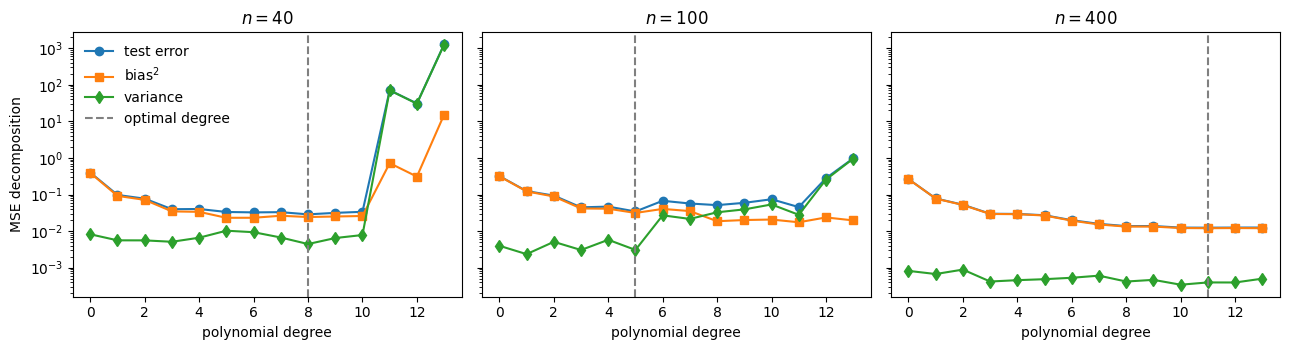

In [522]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=13+1, n_bootstraps=100, make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))

    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))

    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
        
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)): #trying different values of datapoints
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, 'o-', label='test error')
    ax.plot(range(14), b2, 's-', label=r'bias$^2$')
    ax.plot(range(14), var, 'd-', label='variance')
    ax.set_yscale('log')
    ax.set_title(f'$n = {n_}$')
    ax.set_xlabel('polynomial degree')

    best_deg = np.argmin(err)
    ax.axvline(best_deg, color = 'gray', linestyle = '--', label = 'optimal degree')
    print(f'n={n_}: optimal degree = {best_deg}, min test error = {err[best_deg]:.4g}')

axes[0].set_ylabel('MSE decomposition')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()



### Ex.3.3)

When we increase the number of datapoints, the variance decreases noticeably for high polynomial degrees. This is because the error of the average shrinks as the sample size grows. 

The bias-dominated area stays the same because bias is not affected by the number of data points. The bias is only affected by systematic errors and can only be changed by improving the fit of the model.

The optimal degree is 5 for n=100 and 11 for n=400.

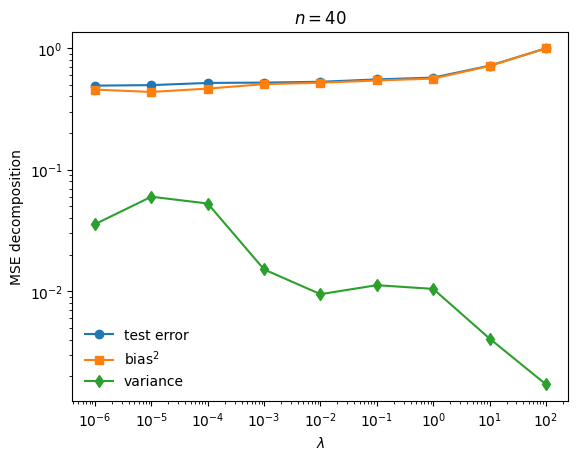

degree = 12, n = 40, 100 bootstraps
lambda        error        bias       variance
--------------------------------------------------
 1e-06 |     0.4911 |     0.4554 |     0.0356
 1e-05 |     0.4958 |     0.4359 |     0.0599
0.0001 |     0.5169 |     0.4643 |     0.0527
 0.001 |     0.5200 |     0.5049 |     0.0151
  0.01 |     0.5282 |     0.5187 |     0.0095
   0.1 |     0.5525 |     0.5412 |     0.0112
   1.0 |     0.5717 |     0.5613 |     0.0105
  10.0 |     0.7161 |     0.7121 |     0.0041
 100.0 |     0.9953 |     0.9936 |     0.0017


In [523]:
def bias_variance_ridge_sweep(n=40, noise=0.1, degree=12+1, lambdas = None, n_bootstraps=100, seed=2026):
    if lambdas is None:
        lambdas = np.logspace(-6, 2, 9)
    """Bootstrap estimate of error/bias^2/variance vs Ridge penalty lambda, at a fixed (high) polynomial degree."""
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
    error, bias, variance = (np.zeros(len(lambdas)) for _ in range(3))

    for k, lam in enumerate(lambdas):
        model = make_pipeline(PolynomialFeatures(degree = degree), StandardScaler(), Ridge(alpha = lam, fit_intercept=False))
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        # Expectations over training sets are averages along axis 1;
        # keepdims=True preserves the column shape and is essential for the bias to come out right.

        error[k] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[k] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[k] = np.mean(np.var(y_pred, axis=1, keepdims=True))
        
    return lambdas, error, bias, variance

lams, err, b2, var = bias_variance_ridge_sweep()

fig, ax = plt.subplots()
ax.plot(lams, err, 'o-', label='test error')
ax.plot(lams, b2, 's-', label=r'bias$^2$')
ax.plot(lams, var, 'd-', label='variance')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(f'$n = {n}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('MSE decomposition')
ax.legend(frameon=False)
plt.show()

print(f'degree = 12, n = 40, 100 bootstraps')
print(f'lambda        error        bias       variance')
print('-' * 50)
for lam in range(len(lams)):
    print(f'{lams[lam]:>6} | {err[lam]:10.4f} | {b2[lam]:10.4f} | {var[lam]:10.4f}')


### Ex.3.4)

An increase in $\lambda$ decreases the variance noticeably. When $\lambda$ shrinks the coefficients of the model, it makes the model less sensitive to the resampled training data. 

$\lambda$ attacks variance at the cost of bias, but only once $\lambda$ is large enough. When $\lambda$ increases and starts to shrink the coefficients, the model is constrained and looses its ability to fit the true signal. Therefore, the bias starts rising. The test error also rises, because it mostly trachs the bias, since the variance is so small. 

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

In [524]:
# Your code for exercise 4 here
from sklearn.metrics import mean_squared_error

def k_fold_cv(model, x, y, k=5, seed = 2026): 
    kf = KFold(n_splits = k, shuffle = True, random_state=seed) #using sklearn's KFold for splitting 
    MSE_folds = np.zeros(k)

    for i, (train_idx, test_idx) in enumerate (kf.split(x)):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(x_train, y_train) #fitting the sklearn estimator
        y_pred = model.predict(x_test).ravel()

        MSE_folds[i] = mean_squared_error(y_test, y_pred)

    return MSE_folds.mean(), MSE_folds.std() #returning mean and std of test across folds



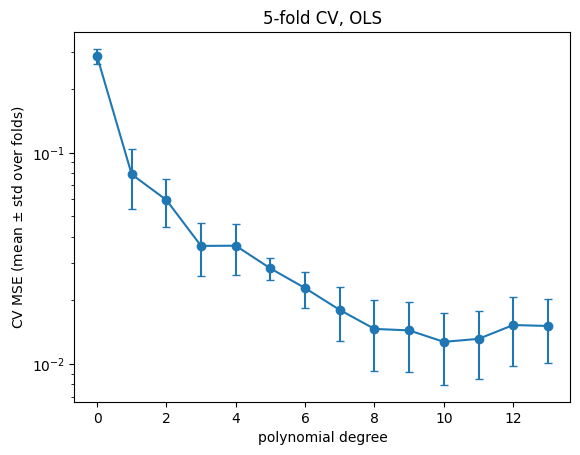

CV-optimal degree: 10, MSE = 0.0127 ± 0.0048


In [525]:
def generate_data(n, noise = 0.1, seed = 2026):
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    return x, y

max_deg = 13+1
cv_mean = np.zeros(max_deg)
cv_std = np.zeros(max_deg)

x, y = generate_data(n=100)
for d in range(max_deg): #going over all degrees
    model = make_pipeline(PolynomialFeatures(degree = d), LinearRegression(fit_intercept=False))
    cv_mean[d], cv_std[d] = k_fold_cv(model, x, y, k=5)

plt.errorbar(range(max_deg), cv_mean, yerr = cv_std, fmt = 'o-', capsize = 3)
plt.yscale('log')
plt.xlabel('polynomial degree')
plt.ylabel(r'CV MSE (mean $\pm$ std over folds)')
plt.title('5-fold CV, OLS')
plt.show()

best_deg = np.argmin(cv_mean)
print(f'CV-optimal degree: {best_deg}, MSE = {cv_mean[best_deg]:.4f} \u00B1 {cv_std[best_deg]:.4f}')





### Ex.4.2)

The bootstrap- and CV methods point to the same degree window for polynomial degrees up to 10. For higher degrees than this, the bootstrap method is dominated by variance and increases. 

Both methods estimate the same generalization error via resampling, but with different resampling schemes (partition without replacement, and resample with replacement).


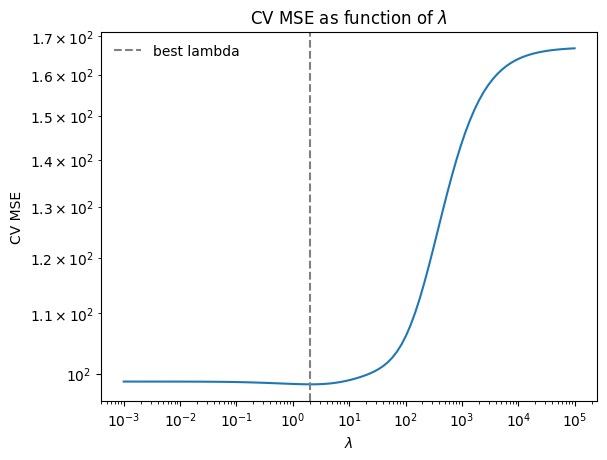

Optimal lambda: 2.0565, CV MSE: 98.3438


In [529]:
def ridge_model(alpha):
    return make_pipeline(PolynomialFeatures(degree = 6), StandardScaler(), Ridge(alpha = alpha, fit_intercept=False))

np.random.seed(2026)
n = 100
x = np.random.uniform(-3, 3, n).reshape(-1, 1)
y = 3 * x**2 + np.random.normal(0, 1, x.shape)

lambdas = np.logspace(-3, 5, 100)
cv_mse = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas): #fitting inside each fold
    model = ridge_model(lam) 
    cv_mse[i], _ = k_fold_cv(model, x, y, k=5)

best_idx = np.argmin(cv_mse)
best_lambda = lambdas[best_idx]

fig, ax = plt.subplots()
ax.plot(lambdas, cv_mse, '-')
ax.axvline(best_lambda, color = 'gray', linestyle = '--', label = 'best lambda')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(r'CV MSE as function of $\lambda$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('CV MSE')
ax.legend(frameon=False)
plt.show()

print(f'Optimal lambda: {best_lambda:.4f}, CV MSE: {cv_mse[best_idx]:.4f}')

### EX.4.3)

The optimal lambda is $\lambda = 2.05$.

The scaling must be fit inside each fold because the StandardScaler learns its mean and standard deviation from the data it is fit on. 

If you fit the scaler once on the full dataset before splitting into folds, the scaling parameters of each fold's training set are computed using information from that fold's test set too This makes the CV estimate biased, because the fold is no longer being evaluated on unseen data. Fitting StandardScaler inside each fold keeps it's the test data completely untouched during training.

In [532]:
for k in [5, 10, n]: #trying different values of k
    lambdas = np.logspace(-3, 5, 100)
    cv_mse = np.zeros(len(lambdas))
    std = np.zeros(len(lambdas))

    for i, lam in enumerate(lambdas):
        model = ridge_model(lam)
        cv_mse[i], std[i] = k_fold_cv(model, x, y, k = k)

    best_idx = np.argmin(cv_mse)
    print(f'k = {k}: optimal lambda = {lambdas[best_idx]:.4f}, MSE = {cv_mse[best_idx]:.4f} ')


k = 5: optimal lambda = 2.0565, MSE = 98.3438 
k = 10: optimal lambda = 1.7074, MSE = 98.0395 
k = 100: optimal lambda = 0.0010, MSE = 97.7560 


### Ex.4.4)

The selected $\lambda$ is not very stable as it changes a lot when we increase k. 

The MSE, on the other hand, is very stable. As k increases toward n, each fold's training set consists of a bigger portion of the full dataset. Training sets across folds become almost identical, which tends to reduce the variance of the CV estimate itself. 

The computational cost increases with k, since we refit the model k times per $\lambda$. 

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.43).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.43) fails?)

In [528]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.